In [ ]:
!pip -q install numpy pandas scipy matplotlib torch

import os, ast, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, stft

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE = "/content/drive/MyDrive/Colab Notebooks"

X_path = f"{BASE}/X_ptbxl_500hz.npy"
X = np.load(X_path, mmap_mode="r")

print("X shape:", X.shape)  # (N, 12, 5000)

X shape: (21799, 12, 5000)


In [ ]:
df = pd.read_csv(f"{BASE}/ptbxl_database.csv")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

classes = ["NORM", "IMI", "ASMI", "LVH", "NDT", "LAFB"]
class_to_idx = {c:i for i,c in enumerate(classes)}

Y = np.zeros((len(df), len(classes)), dtype=np.float32)

for i, codes in enumerate(df["scp_codes"]):
    # codes is a dict like {"NORM": 100.0, "LAFB": 50.0, ...}
    for c in classes:
        if c in codes:
            Y[i, class_to_idx[c]] = 1.0

print("Y shape:", Y.shape)  # (21799, 6)
print("Counts:", dict(zip(classes, Y.sum(axis=0).astype(int))))

# ensure alignment with X
assert X.shape[0] == Y.shape[0]
np.save(f"{BASE}/Y_6labels.npy", Y)

Y shape: (21799, 6)
Counts: {'NORM': np.int64(9514), 'IMI': np.int64(2676), 'ASMI': np.int64(2357), 'LVH': np.int64(2132), 'NDT': np.int64(1825), 'LAFB': np.int64(1623)}


In [ ]:
def bandpass_filter(x, fs=500, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x, axis=0)

In [ ]:
def ecg_to_spectrogram_tensor(ecg_time_leads, fs=500, win_len=256, hop=128, nfft=512, fmax=40.0):
    specs = []
    for lead in range(ecg_time_leads.shape[1]):  # 12 leads
        f, tt, Z = stft(
            ecg_time_leads[:, lead],
            fs=fs,
            nperseg=win_len,
            noverlap=win_len-hop,
            nfft=nfft,
            boundary=None,
            padded=False
        )
        mag = np.abs(Z)  # (freq, time)

        keep = f <= fmax
        mag = mag[keep, :]

        mag = np.log1p(mag)
        mag = (mag - mag.mean()) / (mag.std() + 1e-8)

        specs.append(mag.astype(np.float32))

    return np.stack(specs, axis=0)  # (12, F, T)

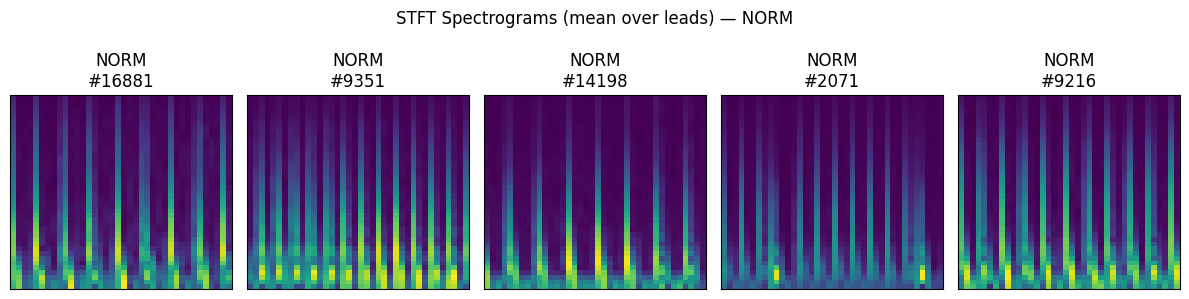

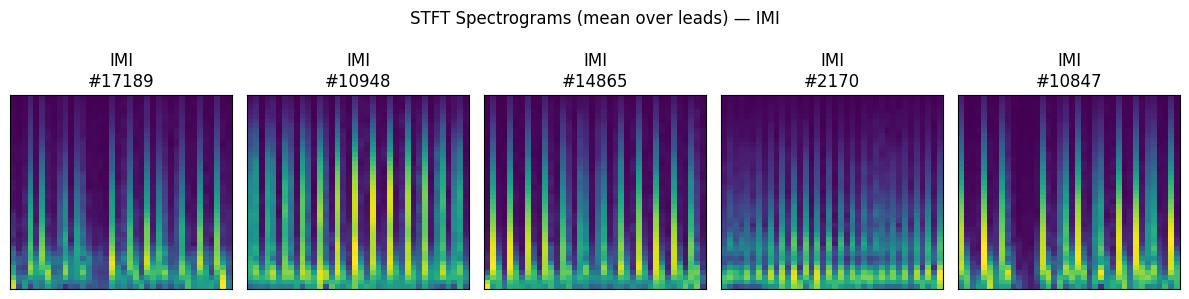

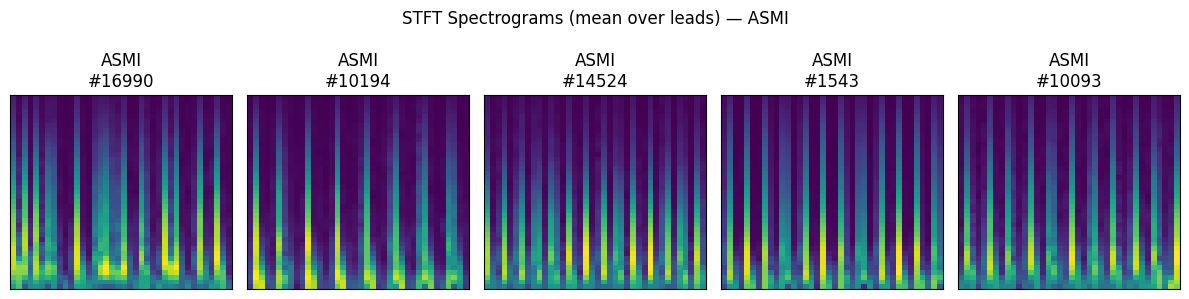

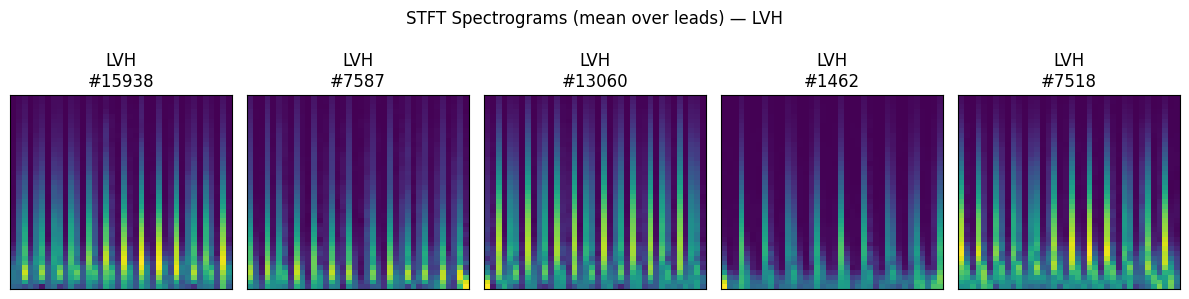

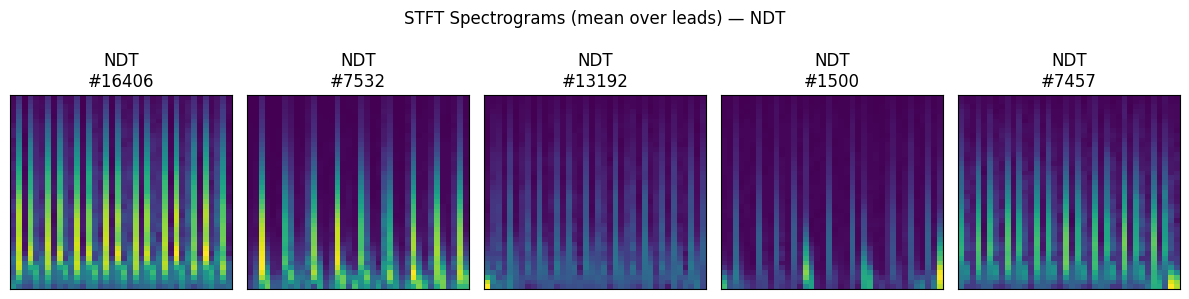

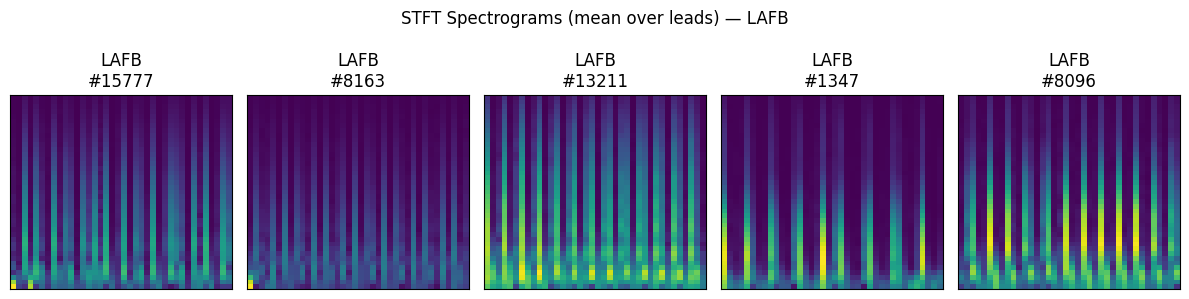

In [ ]:
def idx_to_spec_image(idx, fs=500):
    ecg = X[idx].T  # (5000, 12)
    ecg_filt = bandpass_filter(ecg, fs=fs, low=0.5, high=40.0)
    ecg_filt = (ecg_filt - ecg_filt.mean(axis=0)) / (ecg_filt.std(axis=0) + 1e-8)
    spec = ecg_to_spectrogram_tensor(ecg_filt, fs=fs)  # (12,41,38)
    img = spec.mean(axis=0)  # (41,38) for visualization
    return img

def pick_k_indices_for_class(Y, class_idx, k=5, seed=0):
    rng = np.random.default_rng(seed)
    candidates = np.where(Y[:, class_idx] == 1)[0]
    if len(candidates) == 0:
        return []
    k = min(k, len(candidates))
    return rng.choice(candidates, size=k, replace=False).tolist()

for c in classes:
    idxs = pick_k_indices_for_class(Y, class_to_idx[c], k=5, seed=42)
    if not idxs:
        print(f"No samples found for {c}")
        continue

    plt.figure(figsize=(12, 3))
    for j, idx in enumerate(idxs):
        img = idx_to_spec_image(idx)
        ax = plt.subplot(1, len(idxs), j+1)
        ax.imshow(img, aspect="auto", origin="lower")
        ax.set_title(f"{c}\n#{idx}")
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f"STFT Spectrograms (mean over leads) — {c}")
    plt.tight_layout()
    plt.show()

In [ ]:
class PTBXLSpectrogramDataset(Dataset):
    def __init__(self, X_mmap, Y, fs=500):
        self.X = X_mmap
        self.Y = Y
        self.fs = fs

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        ecg = self.X[idx].T  # (5000, 12)

        ecg_filt = bandpass_filter(ecg, fs=self.fs, low=0.5, high=40.0)
        ecg_filt = (ecg_filt - ecg_filt.mean(axis=0)) / (ecg_filt.std(axis=0) + 1e-8)

        spec = ecg_to_spectrogram_tensor(ecg_filt, fs=self.fs)  # (12,41,38)

        x = torch.from_numpy(spec)                 # float32
        y = torch.from_numpy(self.Y[idx]).float()  # (6,)

        return x, y

In [ ]:
class PTBXLSpectrogramDataset(Dataset):
    def __init__(self, X_mmap, Y, fs=500):
        self.X = X_mmap
        self.Y = Y
        self.fs = fs

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        ecg = self.X[idx].T  # (5000, 12)

        ecg_filt = bandpass_filter(ecg, fs=self.fs, low=0.5, high=40.0)
        ecg_filt = (ecg_filt - ecg_filt.mean(axis=0)) / (ecg_filt.std(axis=0) + 1e-8)

        spec = ecg_to_spectrogram_tensor(ecg_filt, fs=self.fs)  # (12,41,38)

        x = torch.from_numpy(spec)                 # float32
        y = torch.from_numpy(self.Y[idx]).float()  # (6,)

        return x, y

In [ ]:
ecg = X[0].T
ecg_filt = bandpass_filter(ecg, fs=500)
ecg_filt = (ecg_filt - ecg_filt.mean(axis=0)) / (ecg_filt.std(axis=0) + 1e-8)

spec = ecg_to_spectrogram_tensor(ecg_filt, fs=500)

print("STFT tensor shape (for CNN):", spec.shape)

STFT tensor shape (for CNN): (12, 41, 38)


In [ ]:
# 12 channels (leads)

# 41 frequency bins

# 38 time bins

In [ ]:
img = spec.mean(axis=0)
print("Visualization image shape:", img.shape)

Visualization image shape: (41, 38)


In [ ]:
import torch

x = torch.from_numpy(spec).unsqueeze(0)  # add batch dimension
print("With batch dimension:", x.shape)

With batch dimension: torch.Size([1, 12, 41, 38])


In [ ]:
# All STFT spectrograms have fixed dimension (12, 41, 38).
#  Since ECG length is constant (10 seconds at 500 Hz), no padding or resizing is required.
#  The CNN receives 12-channel inputs directly.

In [ ]:
from sklearn.model_selection import train_test_split

idx = np.arange(X.shape[0])
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42)

train_ds = PTBXLSpectrogramDataset(X, Y)
val_ds   = PTBXLSpectrogramDataset(X, Y)

# Subset via indices
train_loader = DataLoader(torch.utils.data.Subset(train_ds, train_idx), batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(torch.utils.data.Subset(val_ds, val_idx), batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
class SmallSpecCNN(nn.Module):
    def __init__(self, n_classes=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(12, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SmallSpecCNN(n_classes=len(classes)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0

    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)

for epoch in range(1, 30):
    tr_loss = run_epoch(train_loader, training=True)
    va_loss = run_epoch(val_loader, training=False)
    print(f"Epoch {epoch}: train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}")

Epoch 1: train_loss=0.2143  val_loss=0.2313
Epoch 2: train_loss=0.2108  val_loss=0.2245
Epoch 3: train_loss=0.2066  val_loss=0.2250
Epoch 4: train_loss=0.2043  val_loss=0.2389
Epoch 5: train_loss=0.2008  val_loss=0.2236
Epoch 6: train_loss=0.1983  val_loss=0.2396
Epoch 7: train_loss=0.1945  val_loss=0.2184
Epoch 8: train_loss=0.1919  val_loss=0.2161
Epoch 9: train_loss=0.1887  val_loss=0.2189
Epoch 10: train_loss=0.1858  val_loss=0.2189
Epoch 11: train_loss=0.1833  val_loss=0.2216
Epoch 12: train_loss=0.1822  val_loss=0.2185
Epoch 13: train_loss=0.1775  val_loss=0.2231
Epoch 14: train_loss=0.1751  val_loss=0.2352
Epoch 15: train_loss=0.1731  val_loss=0.2282
Epoch 16: train_loss=0.1704  val_loss=0.2313
Epoch 17: train_loss=0.1678  val_loss=0.2514
Epoch 18: train_loss=0.1649  val_loss=0.2267
Epoch 19: train_loss=0.1635  val_loss=0.2507
Epoch 20: train_loss=0.1598  val_loss=0.2296
Epoch 21: train_loss=0.1579  val_loss=0.2332
Epoch 22: train_loss=0.1549  val_loss=0.2479
Epoch 23: train_los

In [ ]:
import numpy as np
import torch

def get_val_outputs(model, loader):
    model.eval()
    all_probs = []
    all_true = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_true.append(yb.numpy())
    return np.vstack(all_true), np.vstack(all_probs)

y_true, y_prob = get_val_outputs(model, val_loader)
print("y_true:", y_true.shape, "y_prob:", y_prob.shape)

y_true: (4360, 6) y_prob: (4360, 6)


In [ ]:
from sklearn.metrics import roc_auc_score

aurocs = []
for k, name in enumerate(classes):
    # roc_auc_score needs both classes present; handle edge case
    if len(np.unique(y_true[:, k])) < 2:
        print(f"{name}: AUROC not defined (only one label present in val)")
        continue
    auc = roc_auc_score(y_true[:, k], y_prob[:, k])
    aurocs.append(auc)
    print(f"{name}: AUROC = {auc:.4f}")

if aurocs:
    print("Macro AUROC:", np.mean(aurocs))

NORM: AUROC = 0.9270
IMI: AUROC = 0.8727
ASMI: AUROC = 0.9319
LVH: AUROC = 0.8592
NDT: AUROC = 0.8807
LAFB: AUROC = 0.9774
Macro AUROC: 0.9081291965669513


In [ ]:
from sklearn.metrics import f1_score

y_pred = (y_prob >= 0.5).astype(int)

for k, name in enumerate(classes):
    f1 = f1_score(y_true[:, k], y_pred[:, k], zero_division=0)
    print(f"{name}: F1 = {f1:.4f}")

print("Macro F1:", f1_score(y_true, y_pred, average="macro", zero_division=0))
print("Micro F1:", f1_score(y_true, y_pred, average="micro", zero_division=0))

NORM: F1 = 0.8226
IMI: F1 = 0.4866
ASMI: F1 = 0.6212
LVH: F1 = 0.4180
NDT: F1 = 0.3631
LAFB: F1 = 0.7158
Macro F1: 0.5712109014253235
Micro F1: 0.6755173760249903


In [ ]:
# CNN is training fine on STFT spectrograms: train loss decreased from 0.28→0.22 and val loss from 0.24→0.225 in 5 epochs.
#  Next I’m computing AUROC and F1 per class to judge actual classification performance and handle class imbalance.”

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

print("Per-class metrics:\n")

for k, name in enumerate(classes):
    precision = precision_score(y_true[:, k], y_pred[:, k], zero_division=0)
    recall    = recall_score(y_true[:, k], y_pred[:, k], zero_division=0)
    f1        = f1_score(y_true[:, k], y_pred[:, k], zero_division=0)
    acc       = accuracy_score(y_true[:, k], y_pred[:, k])

    print(f"{name}:")
    print(f"  Precision = {precision:.4f}")
    print(f"  Recall    = {recall:.4f}")
    print(f"  F1-score  = {f1:.4f}")
    print(f"  Accuracy  = {acc:.4f}\n")

print("Overall Metrics:\n")

print("Macro Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))

print("Micro Precision:", precision_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro F1       :", f1_score(y_true, y_pred, average="micro", zero_division=0))

Per-class metrics:

NORM:
  Precision = 0.8562
  Recall    = 0.7916
  F1-score  = 0.8226
  Accuracy  = 0.8475

IMI:
  Precision = 0.5483
  Recall    = 0.4374
  F1-score  = 0.4866
  Accuracy  = 0.8901

ASMI:
  Precision = 0.6043
  Recall    = 0.6392
  F1-score  = 0.6212
  Accuracy  = 0.9133

LVH:
  Precision = 0.6471
  Recall    = 0.3087
  F1-score  = 0.4180
  Accuracy  = 0.9227

NDT:
  Precision = 0.3758
  Recall    = 0.3512
  F1-score  = 0.3631
  Accuracy  = 0.9050

LAFB:
  Precision = 0.6295
  Recall    = 0.8293
  F1-score  = 0.7158
  Accuracy  = 0.9495

Overall Metrics:

Macro Precision: 0.6101981898642236
Macro Recall   : 0.5595568676021547
Macro F1       : 0.5712109014253235
Micro Precision: 0.7072771872444807
Micro Recall   : 0.6464872944693573
Micro F1       : 0.6755173760249903


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

# Threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

print("Per-class metrics:\n")

per_class_acc = []   # store accuracies

for k, name in enumerate(classes):
    precision = precision_score(y_true[:, k], y_pred[:, k], zero_division=0)
    recall    = recall_score(y_true[:, k], y_pred[:, k], zero_division=0)
    f1        = f1_score(y_true[:, k], y_pred[:, k], zero_division=0)
    acc       = accuracy_score(y_true[:, k], y_pred[:, k])

    per_class_acc.append(acc)   # collect

    print(f"{name}:")
    print(f"  Precision = {precision:.4f}")
    print(f"  Recall    = {recall:.4f}")
    print(f"  F1-score  = {f1:.4f}")
    print(f"  Accuracy  = {acc:.4f}\n")

# Macro Accuracy
macro_accuracy = np.mean(per_class_acc)

print("Overall Metrics:\n")

print("Macro Accuracy :", macro_accuracy)   # ✅ added
print("Macro Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))

print("Micro Precision:", precision_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro F1       :", f1_score(y_true, y_pred, average="micro", zero_division=0))

Per-class metrics:

NORM:
  Precision = 0.8562
  Recall    = 0.7916
  F1-score  = 0.8226
  Accuracy  = 0.8475

IMI:
  Precision = 0.5483
  Recall    = 0.4374
  F1-score  = 0.4866
  Accuracy  = 0.8901

ASMI:
  Precision = 0.6043
  Recall    = 0.6392
  F1-score  = 0.6212
  Accuracy  = 0.9133

LVH:
  Precision = 0.6471
  Recall    = 0.3087
  F1-score  = 0.4180
  Accuracy  = 0.9227

NDT:
  Precision = 0.3758
  Recall    = 0.3512
  F1-score  = 0.3631
  Accuracy  = 0.9050

LAFB:
  Precision = 0.6295
  Recall    = 0.8293
  F1-score  = 0.7158
  Accuracy  = 0.9495

Overall Metrics:

Macro Accuracy : 0.9047018348623852
Macro Precision: 0.6101981898642236
Macro Recall   : 0.5595568676021547
Macro F1       : 0.5712109014253235
Micro Precision: 0.7072771872444807
Micro Recall   : 0.6464872944693573
Micro F1       : 0.6755173760249903


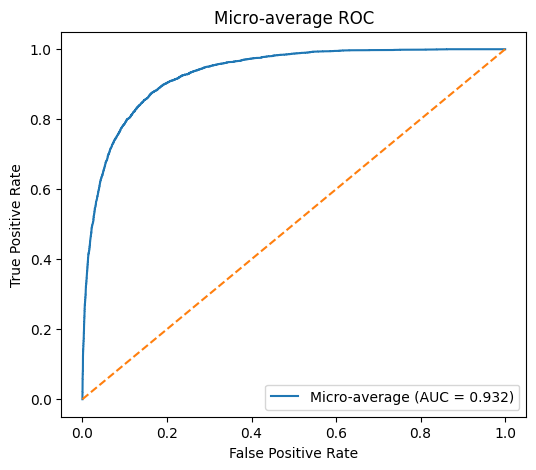

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

fpr_micro, tpr_micro, _ = roc_curve(y_true.ravel(), y_prob.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

plt.figure(figsize=(6,5))
plt.plot(fpr_micro, tpr_micro, label=f"Micro-average (AUC = {auc_micro:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-average ROC")
plt.legend()
plt.show()

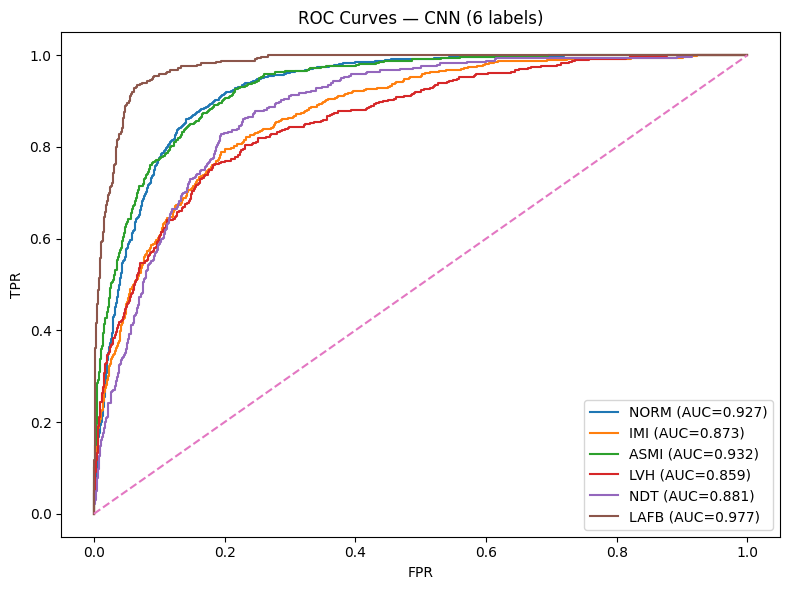

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))
for k, name in enumerate(classes):
    if len(np.unique(y_true[:, k])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true[:, k], y_prob[:, k])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curves — CNN (6 labels)")
plt.legend()
plt.tight_layout()
plt.savefig("roc_stft_cnn.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

best_thresh = np.zeros(len(classes))
for k in range(len(classes)):
    p, r, th = precision_recall_curve(y_true[:, k], y_prob[:, k])
    f1 = 2*p*r/(p+r+1e-8)
    j = np.argmax(f1)
    best_thresh[k] = th[j] if j < len(th) else 0.5

print("Best thresholds:", dict(zip(classes, best_thresh)))

y_pred_tuned = (y_prob >= best_thresh).astype(int)
print("Macro F1 tuned:", f1_score(y_true, y_pred_tuned, average="macro", zero_division=0))
print("Micro F1 tuned:", f1_score(y_true, y_pred_tuned, average="micro", zero_division=0))

Best thresholds: {'NORM': np.float64(0.1421561986207962), 'IMI': np.float64(0.33235791325569153), 'ASMI': np.float64(0.37168651819229126), 'LVH': np.float64(0.1972261518239975), 'NDT': np.float64(0.20046234130859375), 'LAFB': np.float64(0.5636964440345764)}
Macro F1 tuned: 0.6070140311526865
Micro F1 tuned: 0.6886503067484663


In [ ]:
pos = Y[train_idx].sum(axis=0)
neg = len(train_idx) - pos
pos_weight = torch.tensor(neg / (pos + 1e-8), dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print("pos_weight:", dict(zip(classes, pos_weight.cpu().numpy())))

pos_weight: {'NORM': np.float32(1.3049167), 'IMI': np.float32(7.08484), 'ASMI': np.float32(8.315705), 'LVH': np.float32(9.022414), 'NDT': np.float32(10.711887), 'LAFB': np.float32(12.529093)}


<!-- All STFT spectrograms have fixed dimension (12, 41, 38). Since ECG length is constant (10 seconds at 500 Hz), no padding or resizing is required. The CNN receives 12-channel inputs directly. -->